# Phase 6: Model Interpretability via Grad-CAM

This notebook generates Visual Explanations (heatmaps) for our trained EfficientNet-B0 classifier predictions using the **Grad-CAM** algorithm. 

This helps verify that the model is making decisions based on actual leaf infection spots (symptoms) rather than random background pixels.

In [1]:
# Install grad-cam library if missing
%pip install -q grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Setup paths and imports
from pathlib import Path
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, datasets
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils

In [3]:
# Load accelerator and best model
device = utils.device.get_device()

def build_classifier(num_classes):
    model = models.efficientnet_b0()
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

import torchvision.models as models
model = build_classifier(utils.config.NUM_CLASSES).to(device)

if utils.config.BEST_MODEL_PATH.exists():
    checkpoint = torch.load(str(utils.config.BEST_MODEL_PATH), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded model weights successfully.")
else:
    print("⚠️ Warning: Model weights not found. Heatmap will be random.")

✅ Loaded model weights successfully.


In [4]:
# Enable gradients for features layer to calculate Grad-CAM
for param in model.features.parameters():
    param.requires_grad = True
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Inference target: O:\Hackthons\KrishiOS\ai\datasets\classification\plantvillage\train\Apple___Apple_scab\01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG


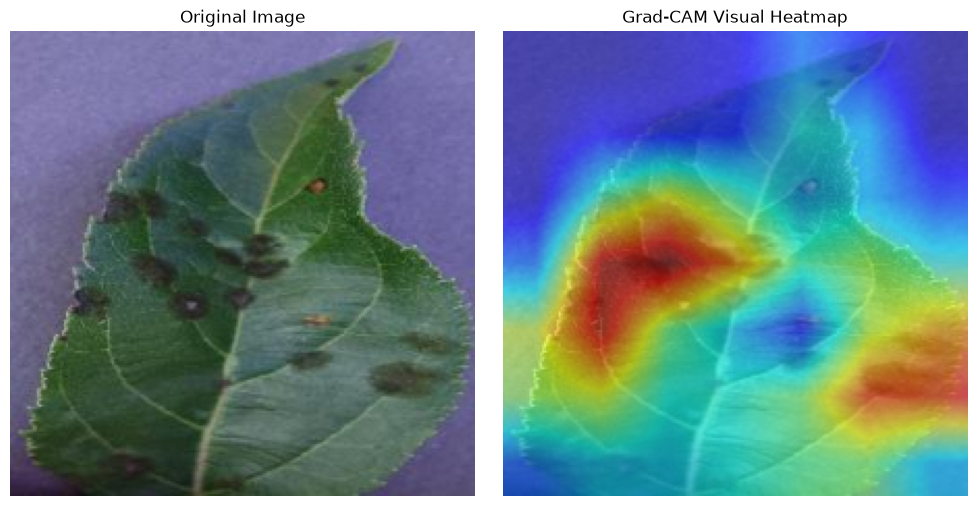

In [5]:
# Pick a test image to run interpretability analysis
dataset = datasets.ImageFolder(str(utils.config.TRAIN_DIR))
class_names = dataset.classes

# Find first image in the first category folder
first_class_dir = utils.config.TRAIN_DIR / class_names[0]
images = list(first_class_dir.glob("*"))

if images:
    image_path = images[0]
    print("Inference target:", image_path)
    
    # Preprocess image
    transform = transforms.Compose([
        transforms.Resize((utils.config.IMAGE_SIZE, utils.config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_pil = Image.open(image_path).convert("RGB")
    rgb_image = np.array(img_pil.resize((utils.config.IMAGE_SIZE, utils.config.IMAGE_SIZE))) / 255.0
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)
    
    # Select target convolution layer (last conv layer in EfficientNet-B0)
    target_layers = [model.features[8][0]]
    
    # Initialize GradCAM engine
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    
    # Render visual overlap
    cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
    
    # Display side-by-side comparison
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(rgb_image)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    ax[1].imshow(cam_image)
    ax[1].set_title("Grad-CAM Visual Heatmap")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No training images found to display heatmaps.")